In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.summary()

/Users/tanishqbakshi/CNN_PROJECT/.venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [5]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/raw/training_set/training_set",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/raw/training_set/training_set",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/raw/test_set/test_set",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Found 2023 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [7]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history_mobile = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 108s 535ms/step - accuracy: 0.9685 - loss: 0.1036 - val_accuracy: 0.9813 - val_loss: 0.0600
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 95s 473ms/step - accuracy: 0.9806 - loss: 0.0541 - val_accuracy: 0.9813 - val_loss: 0.0532
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 116s 580ms/step - accuracy: 0.9831 - loss: 0.0469 - val_accuracy: 0.9825 - val_loss: 0.0460
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 103s 512ms/step - accuracy: 0.9845 - loss: 0.0434 - val_accuracy: 0.9819 - val_loss: 0.0450
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 104s 520ms/step - accuracy: 0.9859 - loss: 0.0387 - val_accuracy: 0.9806 - val_loss: 0.0445


In [13]:
test_loss_mobile, test_accuracy_mobile = mobilenet_model.evaluate(test_ds)

print("MobileNet Test Accuracy:", test_accuracy_mobile)
print("MobileNet Test Loss:", test_loss_mobile)

64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.9871 - loss: 0.0394
MobileNet Test Accuracy: 0.9871478080749512
MobileNet Test Loss: 0.03943069651722908


In [14]:
mobilenet_model.save("../models/mobilenet_model.keras")

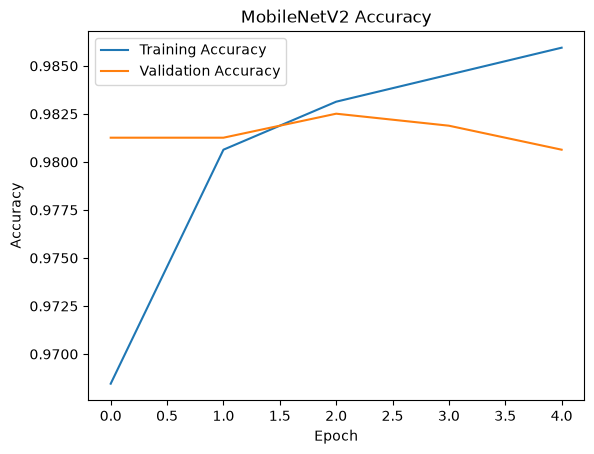

In [15]:
import matplotlib.pyplot as plt

plt.plot(history_mobile.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobile.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("MobileNetV2 Accuracy")

plt.show()

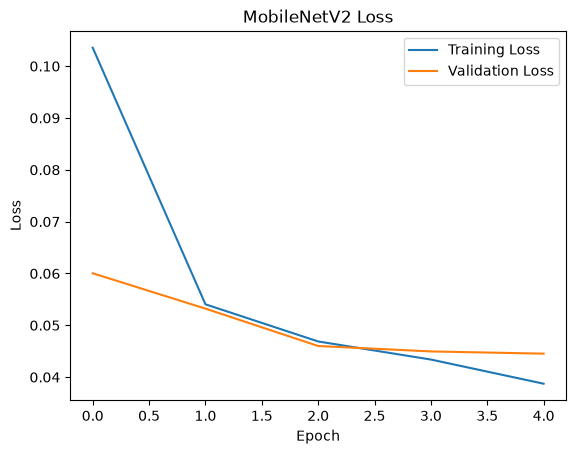

In [16]:
plt.plot(history_mobile.history["loss"], label="Training Loss")
plt.plot(history_mobile.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("MobileNetV2 Loss")

plt.show()